## Загрузка и описание данных

In [4]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/raw/credit_data.csv", delimiter=";")

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

### О данных

German Credit Data — датасет с 1000 заявками на кредит и 20 признаками, описывающими профиль заявителя. Задача — бинарная классификация: определить, является ли заявитель хорошим (Good) или плохим (Bad) кредитным риском.

Ключевые признаки:

- Account Balance — состояние счета (нет счета / нулевой баланс / есть баланс)
- Payment Status — история платежей (проблемы / погашено / без проблем)
- Savings/Stock Value — размер сбережений
- Employment Length — стаж работы
- Sex/Marital Status — пол и семейное положение
- Guarantor — наличие поручителя
- Concurrent Credits — другие текущие кредиты
- Purpose — цель кредита (новая машина, б/у машина, недвижимость, прочее)

Целевая переменная — Creditability (1 = хороший заемщик, 0 = плохой).

Источник: [Penn State STAT 508](https://online.stat.psu.edu/stat508/resource/analysis/gcd)

In [7]:
df.head(7)

,creditability,account_balance,duration_of_credit_monthly,payment_status_of_previous_credit,purpose,credit_amount,value_savings_stocks,length_of_current_employment,instalment_per_cent,sex_marital_status,...,duration_in_current_address,most_valuable_available_asset,age_years,concurrent_credits,type_of_apartment,no_of_credits_at_this_bank,occupation,no_of_dependents,telephone,foreign_worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2
5,1,1,10,4,0,2241,1,2,1,3,...,3,1,48,3,1,2,2,2,1,2
6,1,1,8,4,0,3398,1,4,1,3,...,4,1,39,3,2,2,2,1,1,2


In [8]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   creditability                      1000 non-null   int64
 1   account_balance                    1000 non-null   int64
 2   duration_of_credit_monthly         1000 non-null   int64
 3   payment_status_of_previous_credit  1000 non-null   int64
 4   purpose                            1000 non-null   int64
 5   credit_amount                      1000 non-null   int64
 6   value_savings_stocks               1000 non-null   int64
 7   length_of_current_employment       1000 non-null   int64
 8   instalment_per_cent                1000 non-null   int64
 9   sex_marital_status                 1000 non-null   int64
 10  guarantors                         1000 non-null   int64
 11  duration_in_current_address        1000 non-null   int64
 12  most_valuable_availab

creditability                        0
account_balance                      0
duration_of_credit_monthly           0
payment_status_of_previous_credit    0
purpose                              0
credit_amount                        0
value_savings_stocks                 0
length_of_current_employment         0
instalment_per_cent                  0
sex_marital_status                   0
guarantors                           0
duration_in_current_address          0
most_valuable_available_asset        0
age_years                            0
concurrent_credits                   0
type_of_apartment                    0
no_of_credits_at_this_bank           0
occupation                           0
no_of_dependents                     0
telephone                            0
foreign_worker                       0
dtype: int64

In [9]:
df.describe()

,creditability,account_balance,duration_of_credit_monthly,payment_status_of_previous_credit,purpose,credit_amount,value_savings_stocks,length_of_current_employment,instalment_per_cent,sex_marital_status,...,duration_in_current_address,most_valuable_available_asset,age_years,concurrent_credits,type_of_apartment,no_of_credits_at_this_bank,occupation,no_of_dependents,telephone,foreign_worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


In [12]:
df['occupation'].value_counts()

occupation
3    630
2    200
4    148
1     22
Name: count, dtype: int64

### Таргет

In [ ]:
df['creditability'].value_counts()

creditability
1    700
0    300
Name: count, dtype: int64

### foreign_worker

In [ ]:
df = df.drop(columns=['foreign_worker'])

foreign_worker исключен из анализа: чувствительный признак (иммиграционный статус),
использование которого в кредитном скоринге неэтично и потенциально незаконно
(fair lending / антидискриминационное регулирование), независимо от его предсказательной силы

In [ ]:
df.shape

(1000, 20)

## Анализ признаков

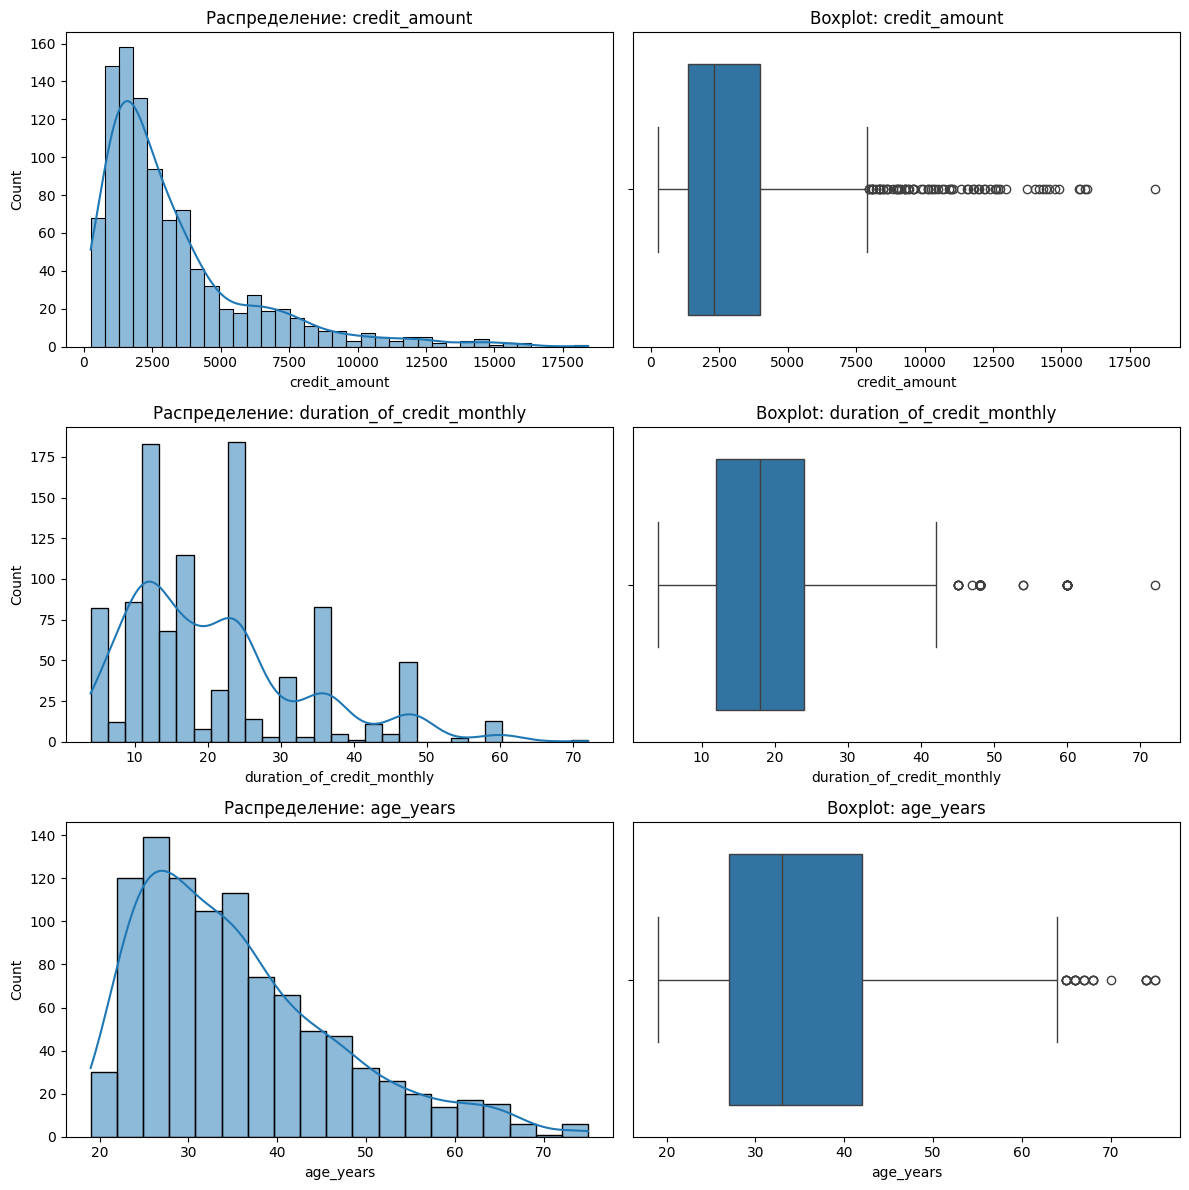

In [ ]:
numerical_cols = ['credit_amount', 'duration_of_credit_monthly', 'age_years']

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0]) # type: ignore
    axes[i, 0].set_title(f'Распределение: {col}')

    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

In [ ]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numerical_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: границы [{lower:.1f}, {upper:.1f}], выбросов = {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

credit_amount: границы [-2544.6, 7882.4], выбросов = 72 (7.2%)
duration_of_credit_monthly: границы [-6.0, 42.0], выбросов = 70 (7.0%)
age_years: границы [4.5, 64.5], выбросов = 23 (2.3%)


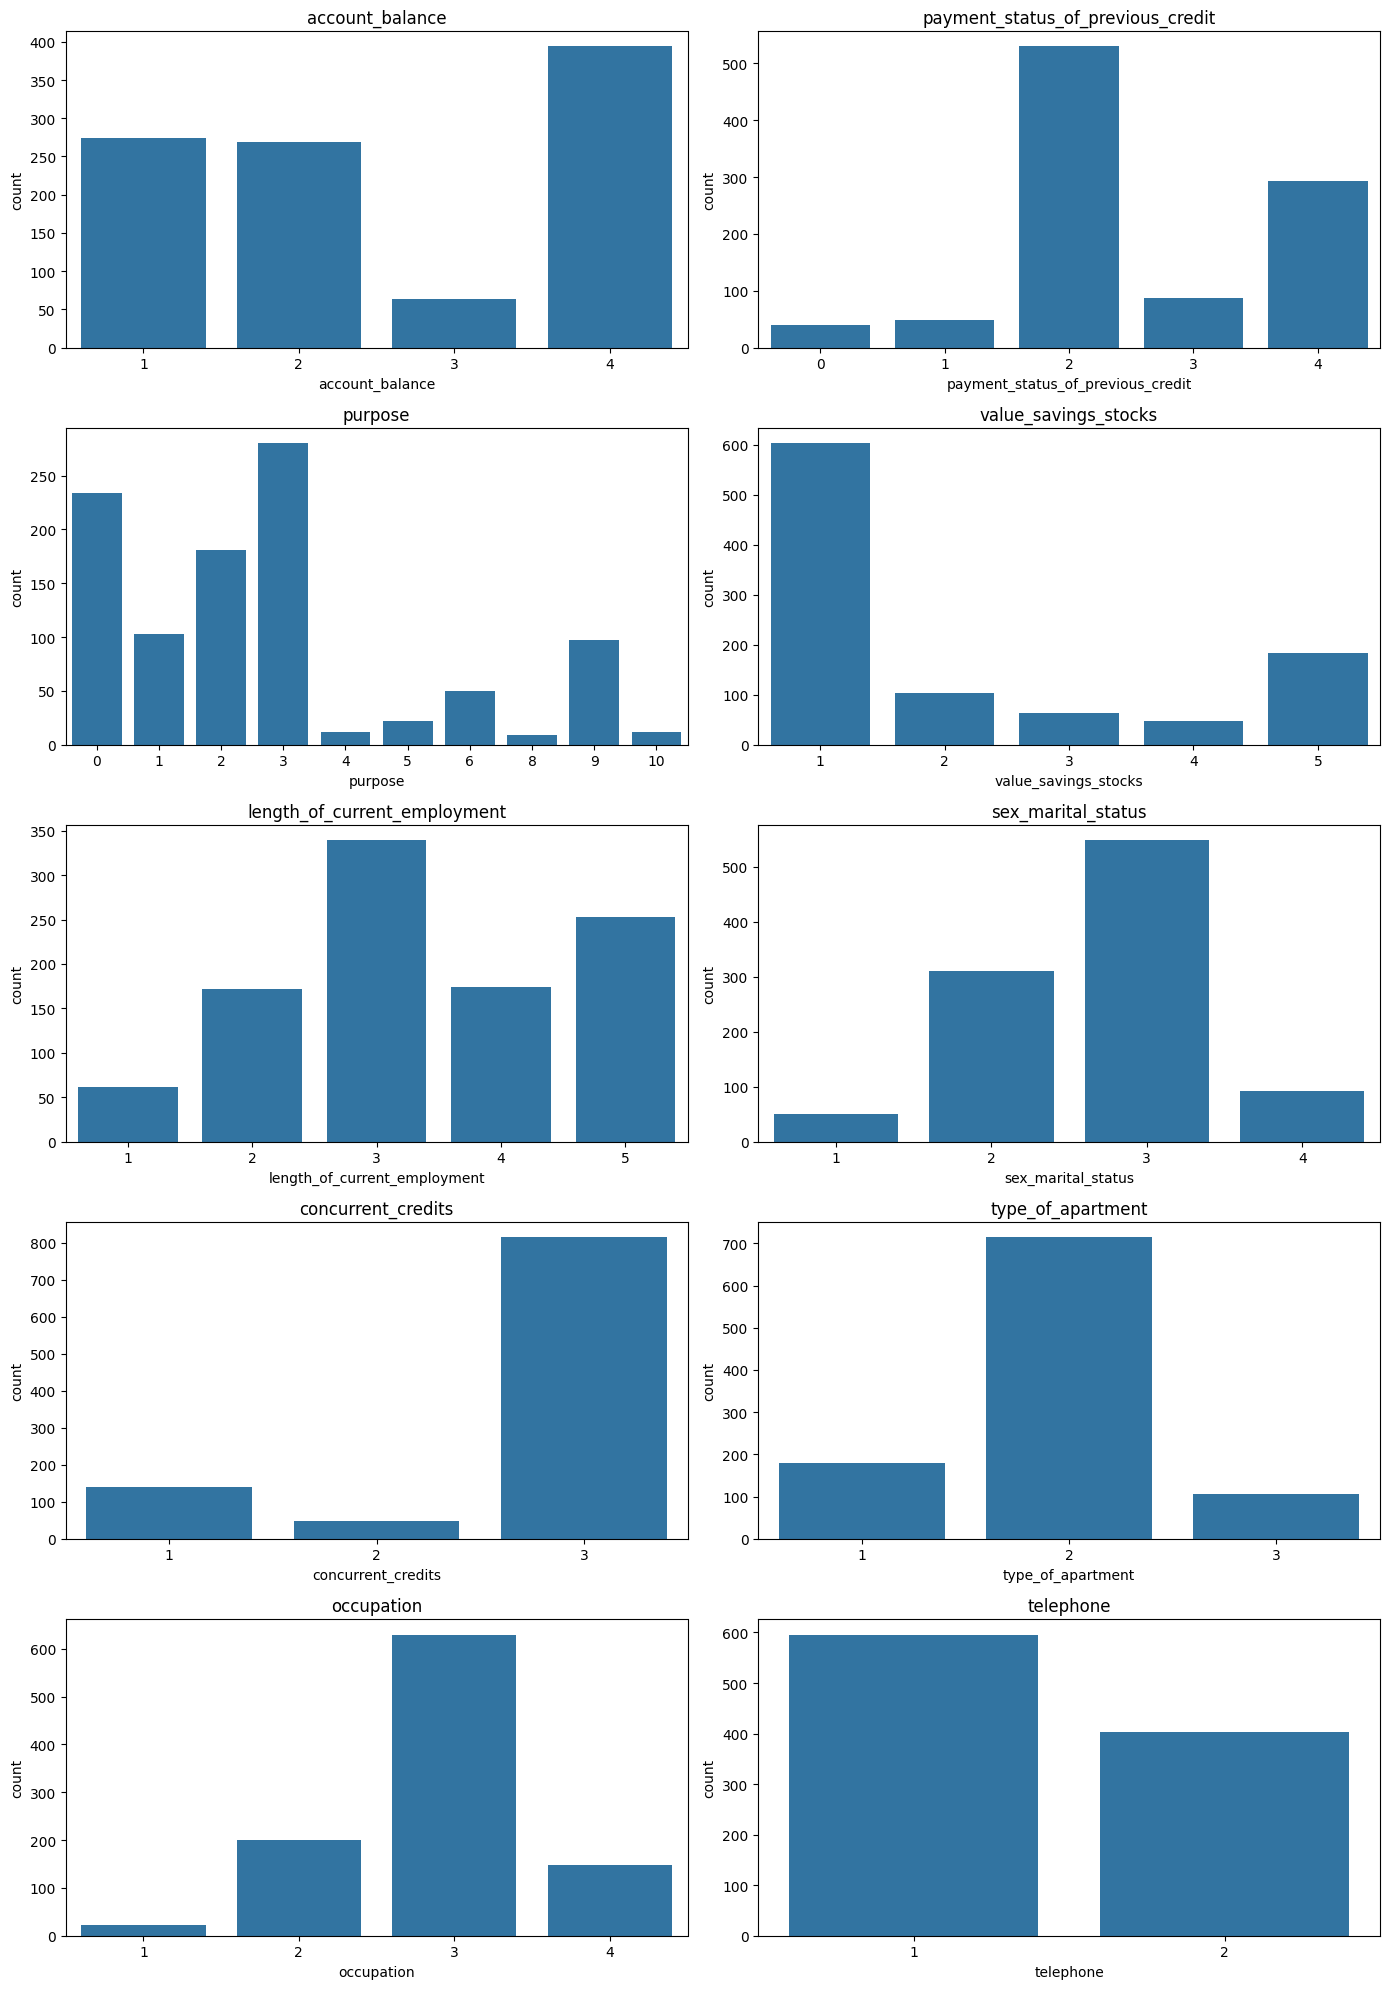

In [ ]:
categorical_cols = ['account_balance', 'payment_status_of_previous_credit', 'purpose',
                     'value_savings_stocks', 'length_of_current_employment',
                     'sex_marital_status', 'concurrent_credits', 'type_of_apartment',
                     'occupation', 'telephone']

fig, axes = plt.subplots(nrows=(len(categorical_cols) + 1) // 2, ncols=2, figsize=(14, 4 * ((len(categorical_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Связь признаков с таргетом

creditability
1    700
0    300
Name: count, dtype: int64
creditability
1    0.7
0    0.3
Name: proportion, dtype: float64


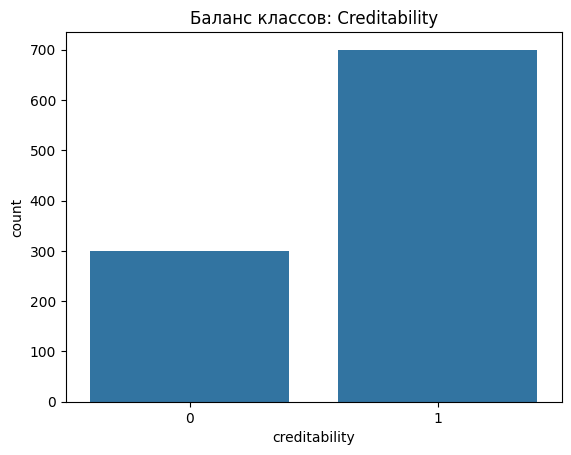

In [ ]:
print(df['creditability'].value_counts())
print(df['creditability'].value_counts(normalize=True))

sns.countplot(x=df['creditability'])
plt.title('Баланс классов: Creditability')
plt.show()


account_balance:
creditability           0         1
account_balance                    
1                0.492701  0.507299
2                0.390335  0.609665
3                0.222222  0.777778
4                0.116751  0.883249


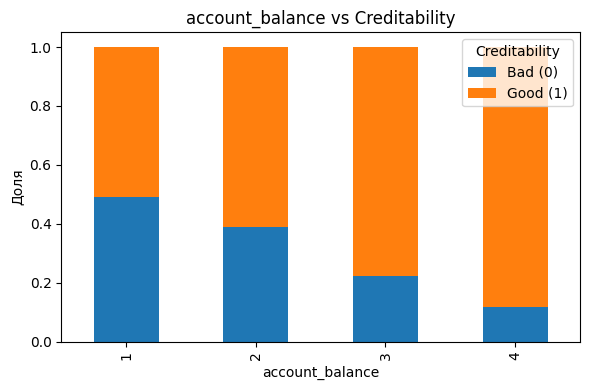


payment_status_of_previous_credit:
creditability                             0         1
payment_status_of_previous_credit                    
0                                  0.625000  0.375000
1                                  0.571429  0.428571
2                                  0.318868  0.681132
3                                  0.318182  0.681818
4                                  0.170648  0.829352


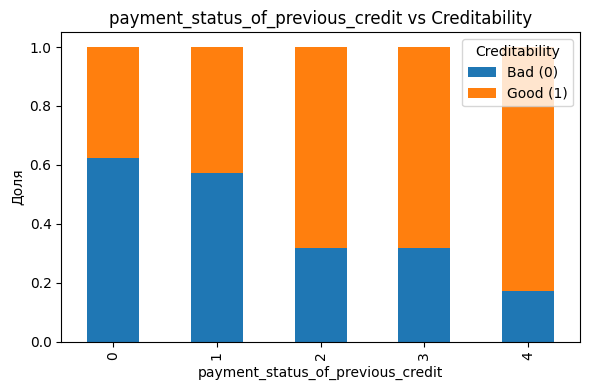


purpose:
creditability         0         1
purpose                          
0              0.380342  0.619658
1              0.165049  0.834951
2              0.320442  0.679558
3              0.221429  0.778571
4              0.333333  0.666667
5              0.363636  0.636364
6              0.440000  0.560000
8              0.111111  0.888889
9              0.350515  0.649485
10             0.416667  0.583333


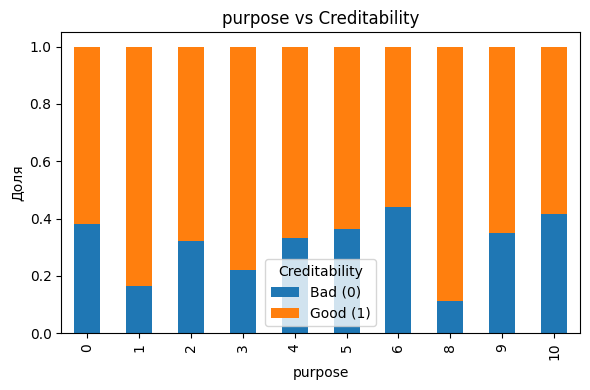


value_savings_stocks:
creditability                0         1
value_savings_stocks                    
1                     0.359867  0.640133
2                     0.330097  0.669903
3                     0.174603  0.825397
4                     0.125000  0.875000
5                     0.174863  0.825137


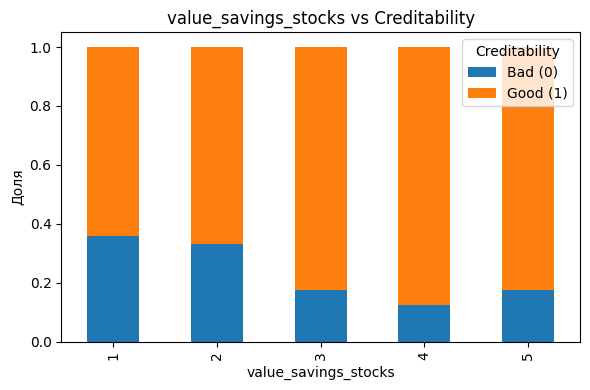


length_of_current_employment:
creditability                        0         1
length_of_current_employment                    
1                             0.370968  0.629032
2                             0.406977  0.593023
3                             0.306785  0.693215
4                             0.224138  0.775862
5                             0.252964  0.747036


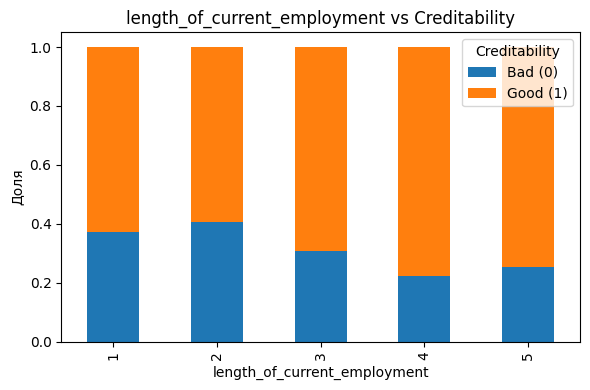

In [ ]:
key_categorical = ['account_balance', 'payment_status_of_previous_credit',
                    'purpose', 'value_savings_stocks', 'length_of_current_employment']

for col in key_categorical:
    ct = pd.crosstab(df[col], df['creditability'], normalize='index')
    print(f"\n{col}:")
    print(ct)

    ct.plot(kind='bar', stacked=True, figsize=(6, 4))
    plt.title(f'{col} vs Creditability')
    plt.ylabel('Доля')
    plt.legend(title='Creditability', labels=['Bad (0)', 'Good (1)'])
    plt.tight_layout()
    plt.show() 

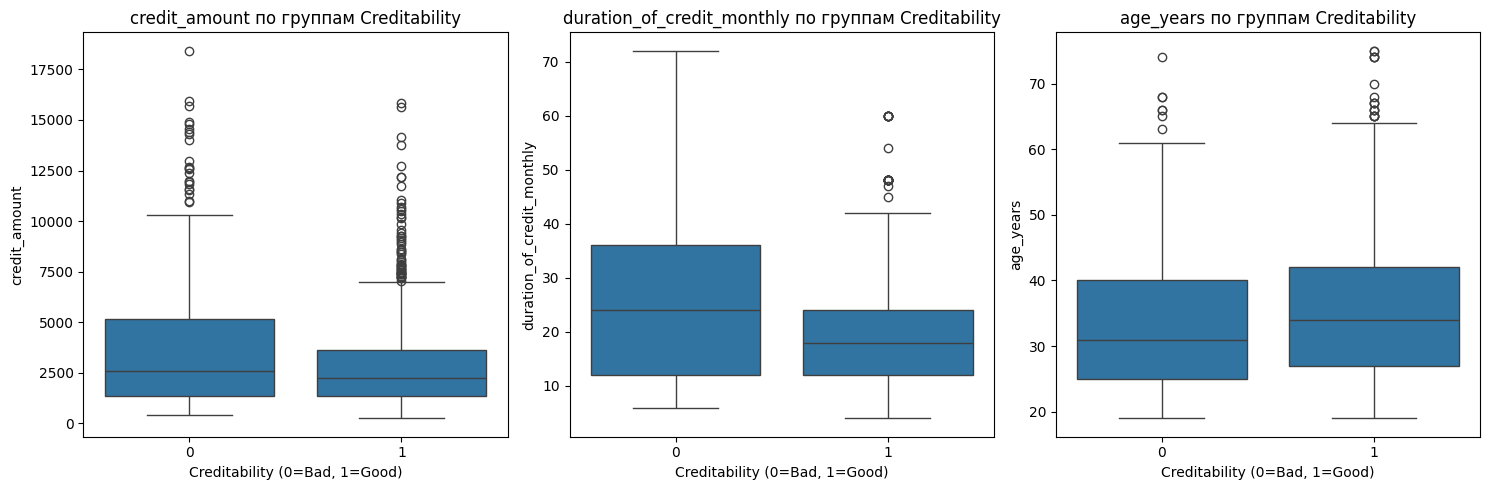

In [ ]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(5 * len(numerical_cols), 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df['creditability'], y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} по группам Creditability')
    axes[i].set_xlabel('Creditability (0=Bad, 1=Good)')

plt.tight_layout()
plt.show()

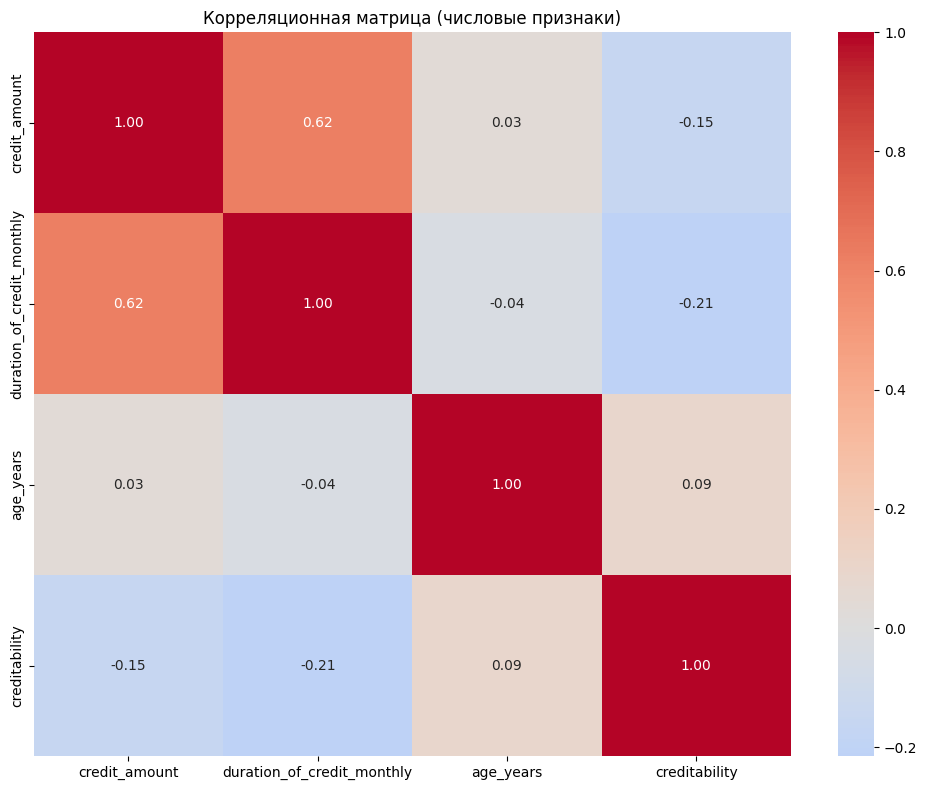

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[numerical_cols + ['creditability']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица (числовые признаки)')
plt.tight_layout()
plt.show()

## Финальный датасет

In [ ]:
def group_rare_categories(df, col, threshold=0.05, new_label=99):
    freq = df[col].value_counts(normalize=True)
    rare_categories = freq[freq < threshold].index
    df[col] = df[col].apply(lambda x: new_label if x in rare_categories else x)
    return df

for col in categorical_cols + ['purpose']:  # purpose явно, т.к. там больше всего редких категорий
    df = group_rare_categories(df, col, threshold=0.05) # type: ignore

# проверка, что сработало
for col in ['purpose']:
    print(df[col].value_counts(normalize=True)) # type: ignore

purpose
3     0.280
0     0.234
2     0.181
1     0.103
9     0.097
99    0.055
6     0.050
Name: proportion, dtype: float64


### Новая фича — платёжная нагрузка

In [ ]:
df['credit_amount_per_month'] = df['credit_amount'] / df['duration_of_credit_monthly']

In [ ]:
df.to_csv("data/credit_data_final.csv", index=False)

## Итог по финальному датасету

- Редкие категории (< 5%) объединены в отдельную группу — в первую очередь коснулось `purpose`, где было несколько малочисленных значений
- `sex_marital_status` оставлен в датасете для учебных целей и анализа feature importance, с пометкой, что в реальном production-скоринге он требует отдельного fairness-review
- Добавлена новая фича `credit_amount_per_month` (credit_amount / duration_of_credit_monthly) — примерная ежемесячная кредитная нагрузка
- Пропусков в данных нет, финальный размер: [впиши актуальный df.shape]
- Датасет сохранён в `data/credit_data_final.csv` — готов к использованию на этапе моделирования